✅ Read file OK | sep=',' | encoding='utf-8'
Columns: ['ID', 'Description', 'GeneRatio', 'BgRatio', 'RichFactor', 'FoldEnrichment', 'zScore', 'pvalue', 'p.adjust', 'qvalue', 'geneID', 'Count', 'SetSize', 'Overlap']
✅ Saved: /Users/linrisheng/Library/CloudStorage/OneDrive-个人/invivo/10x/pRS050-perturb-seq-3targets/Fam50a/20260125/Enrichment2/Sup_-layer_neurons_ALL_GO_BP_FDR0.01_Top10_blankTop_sigTop.pdf


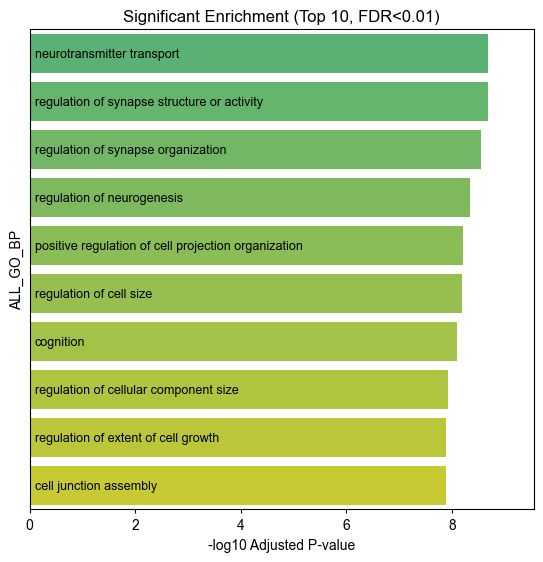

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.transforms import blended_transform_factory
import os

# =========================

# =========================
enrich_txt_path = "./Enrichment/Sup_-layer_neurons/ALL_GO_BP.csv"
outdir = "./Enrichment_figure/"
os.makedirs(outdir, exist_ok=True)

# =========================

# =========================
FDR_CUTOFF = 0.01
TOP_N = 10
FIG_W, FIG_H = 8, 6

LEFT_MARGIN = 0.35
TERM_X_IN_AXES = 0.01
TERM_FONTSIZE = 9

GRAD_START = "#59b273"
GRAD_END = "#c7ca32"

# =========================

# =========================
def smart_read_table(path):

    with open(path, "rb") as f:
        raw = f.read(5000)


    for enc in ["utf-8", "utf-8-sig", "gbk", "gb18030", "latin1"]:
        try:
            text = raw.decode(enc)
            break
        except UnicodeDecodeError:
            text = None
    if text is None:
        raise UnicodeDecodeError("Cannot decode file with common encodings.")


    tab_n = text.count("\t")
    comma_n = text.count(",")
    sep = "\t" if tab_n > comma_n else ","


    for enc in ["utf-8", "utf-8-sig", "gbk", "gb18030", "latin1"]:
        try:
            df = pd.read_csv(path, sep=sep, encoding=enc)
            return df, sep, enc
        except Exception:
            continue

    raise ValueError("Failed to read table with any encoding.")

df, sep_used, enc_used = smart_read_table(enrich_txt_path)
print(f"✅ Read file OK | sep='{sep_used}' | encoding='{enc_used}'")
print("Columns:", df.columns.tolist()[:20])

# =========================

# =========================
required_cols = ["Description", "p.adjust"]
for c in required_cols:
    if c not in df.columns:
        raise ValueError(
            f"你的文件里缺少列: {c}\n当前列名为: {df.columns.tolist()}\n"
            f"（提示：可能是列名不同，比如 'Description' 或 'p.adjust'）"
        )

# =========================

# =========================
df_sig = df[df["p.adjust"] < FDR_CUTOFF].copy()
if df_sig.shape[0] == 0:
    raise ValueError(f"没有筛到显著富集结果（p.adjust < {FDR_CUTOFF}）")

df_sig["-log10P"] = -np.log10(df_sig["p.adjust"].astype(float))


df_sig = df_sig.sort_values("-log10P", ascending=False).copy()

top = df_sig.head(TOP_N).copy()
n = top.shape[0]

x_vals = top["-log10P"].to_numpy()
terms = top["Description"].astype(str).to_list()

# =========================

# =========================
rcParams["font.family"] = "sans-serif"
rcParams["font.sans-serif"] = ["Arial"]
rcParams["font.size"] = 10
rcParams["axes.linewidth"] = 0.8
rcParams["xtick.major.width"] = 0.8
rcParams["ytick.major.width"] = 0.8
rcParams["xtick.major.size"] = 3
rcParams["ytick.major.size"] = 3
rcParams["pdf.fonttype"] = 42
rcParams["ps.fonttype"] = 42

# =========================

# =========================
cmap = LinearSegmentedColormap.from_list("my_grad", [GRAD_START, GRAD_END])
colors = [cmap(i / (n - 1) if n > 1 else 0.5) for i in range(n)]

# =========================

# =========================
y_pos = np.arange(0, n)
x_vals = x_vals[::-1]
terms = terms[::-1]
colors = colors[::-1]

# =========================
# 8) 绘图
# =========================
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.barh(y_pos, x_vals, color=colors, edgecolor="none")

ax.set_title(f"Significant Enrichment (Top {n}, FDR<{FDR_CUTOFF})")
ax.set_xlabel("-log10 Adjusted P-value")


ax.set_ylim(-0.5, TOP_N - 0.5)


xmax = max(float(np.max(x_vals)), 1e-6)
ax.set_xlim(0, xmax * 1.10)


ax.set_yticks([])
ax.tick_params(axis="y", length=0)


y_axis_name = os.path.basename(enrich_txt_path).split(".", 1)[0]
ax.set_ylabel(y_axis_name)


fig.subplots_adjust(left=LEFT_MARGIN, right=0.98, top=0.92, bottom=0.12)

# =========================

# =========================
trans = blended_transform_factory(ax.transAxes, ax.transData)

for y, term in zip(y_pos, terms):
    ax.text(
        TERM_X_IN_AXES, y, term,
        transform=trans,
        va="center", ha="left",
        fontsize=TERM_FONTSIZE,
        color="black",
        clip_on=False
    )

# =========================

# =========================
base_name = os.path.splitext(os.path.basename(enrich_txt_path))[0]
out_pdf = os.path.join(outdir, f"Sup_-layer_neurons_{base_name}_FDR{FDR_CUTOFF}_Top{TOP_N}_blankTop_sigTop.pdf")

plt.savefig(out_pdf)
print(f"✅ Saved: {out_pdf}")

plt.show()
